### 머신러닝 프레임워크 : scikit-learn
 : 다양한 분류(classification) 및 회귀(regression)를 지원하며 검증하는 기능.
 분류, 회귀, 클러스터링, 차원축소가 가능하며 샘플데이터도 제공

#### XOR 연산 학습해보기

In [1]:
xor_input = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]
xor_input

[[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]]

In [2]:
import pandas as pd    # as = 알리아스. pandas 는 .으로 메소드 형식

In [3]:
xor_df = pd.DataFrame(xor_input)
xor_df

,0,1,2
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [6]:
# 데이터 구성(문제)
xor_data = xor_df.loc[:,[0, 1]]
xor_data

,0,1
0,0,0
1,0,1
2,1,0
3,1,1


In [7]:
# 정답
xor_target = xor_df.loc[:,2]   # 시리즈 타입
xor_target

0    0
1    1
2    1
3    0
Name: 2, dtype: int64

In [4]:
# 데이터 학습과 예측하기
from sklearn import svm, metrics

In [13]:
# 모델 만들기
clf = svm.SVC()   # 괄호 안에는 구할 유형에 따라 하이퍼 파라미터를 쓸 때가 있음.

In [8]:
# 학습시키기 ( fit() )
clf.fit(xor_data, xor_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
# 평가
pred = clf.predict(xor_data)
pred

array([0, 1, 1, 0])

In [10]:
# 정답률 구하기
metrics.accuracy_score(xor_target, pred)   # (y, y햇)

1.0

In [12]:
# predict 를 구하지 않고 정답률 구하기
clf.score(xor_data, xor_target)

1.0

----
### 붓꽃의 품종을 분류하기

In [14]:
iris = pd.read_csv('../Data/iris.csv')
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
iris.tail()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [17]:
# 품종의 종류?
iris['Name'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [19]:
# 데이터타입 확인
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Name         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [23]:
# 기본 통계량
iris.describe()
# 평균 / 중앙값이 비슷하면 정규분포 형태 => 분석 ㄱㅊ
# 비슷함 = 둘이 비슷한 값, 혹은 차이가 조금 나더라도 최소 최대 범위가 클 경우.

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [26]:
# NaN(Not a Number) 값 확인
iris.isna().sum()

SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Name           0
dtype: int64

#### Color Feature 추가

In [41]:
# Iris-setosa: red, Iris-versicolor: green, Iris-virginica: blue
color_tmp = []

for name in iris['Name'] :
    # print(name) - 잘 불러왔나 확인
    if name == 'Iris-setosa' : 
        color_tmp.append('red')
    elif name == 'Iris-versicolor' : 
        color_tmp.append('green')
    else: 
        color_tmp.append('blue')
# color_tmp - 확인작업

iris['Color'] = color_tmp
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,Color
0,5.1,3.5,1.4,0.2,Iris-setosa,red
1,4.9,3.0,1.4,0.2,Iris-setosa,red
2,4.7,3.2,1.3,0.2,Iris-setosa,red
3,4.6,3.1,1.5,0.2,Iris-setosa,red
4,5.0,3.6,1.4,0.2,Iris-setosa,red


##### 산포도(산점도, Scatter)

In [49]:
!pip install koreanize-matplotlib  # 패키지를 다운받아서 한글 쓸 수 있게 해주는 거. 아래 import 해줘야 함.

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [48]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

<function matplotlib.pyplot.show(close=None, block=None)>

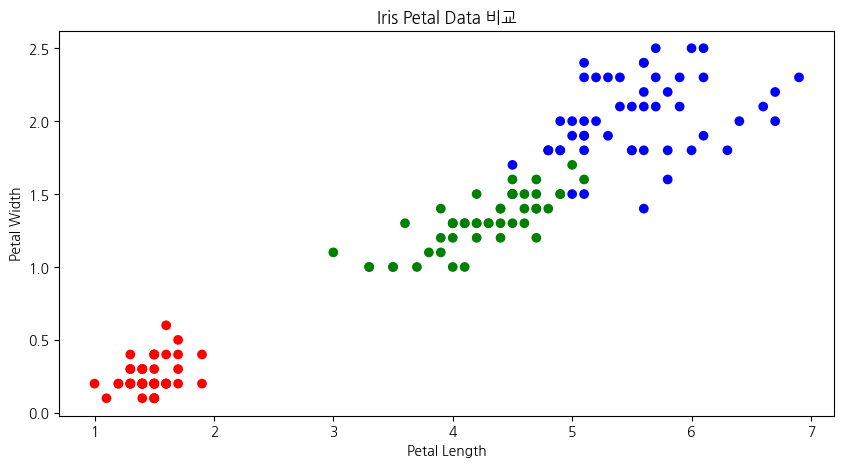

In [50]:
plt.figure(figsize=(10,5))
plt.scatter(
    iris['PetalLength'],
    iris['PetalWidth'],
    c=iris['Color']
)  # 크게 직선형이면 분석 가능
plt.title('Iris Petal Data 비교')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show

##### Machine Learning 을 위한 작업

In [51]:
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,Color
0,5.1,3.5,1.4,0.2,Iris-setosa,red
1,4.9,3.0,1.4,0.2,Iris-setosa,red
2,4.7,3.2,1.3,0.2,Iris-setosa,red
3,4.6,3.1,1.5,0.2,Iris-setosa,red
4,5.0,3.6,1.4,0.2,Iris-setosa,red


In [52]:
# 지도학습의 Feature 만들기
iris_data = iris[
    ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
]
iris_data.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [53]:
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [54]:
# Target
iris_target = iris['Name']
iris_target.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Name, dtype: object

##### 학습용 데이터와 테스트용 데이터로 나누기
- 현재 iris 데이터가 1세트만 있으므로, 그 중에 일부 데이터 빼고 학습시킨 뒤 그 일부 데이터의 결과를 맞추는 테스트를 함. 단, 섞어서 하지 않으면 a, b 학습 시키고 c 를 맞추라 하는 경우가 생기므로 패키지를 이용해서 섞음.

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
train_data, test_data, train_target, test_target = \
train_test_split(iris_data, iris_target)  # 대략 7(train용) : 3(test용) 정도로 나옴  # \ = 줄 이어주는 거

In [57]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 10 to 20
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  112 non-null    float64
 1   SepalWidth   112 non-null    float64
 2   PetalLength  112 non-null    float64
 3   PetalWidth   112 non-null    float64
dtypes: float64(4)
memory usage: 4.4 KB


In [58]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 71 to 98
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  38 non-null     float64
 1   SepalWidth   38 non-null     float64
 2   PetalLength  38 non-null     float64
 3   PetalWidth   38 non-null     float64
dtypes: float64(4)
memory usage: 1.5 KB


##### 학습시키기

In [59]:
clf = svm.SVC()

In [60]:
clf.fit(train_data, train_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
# 예측하기
pred = clf.predict(test_data)
pred[:5]

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor'], dtype=object)

In [62]:
# 정답률 구하기
metrics.accuracy_score(test_target, pred)

0.8947368421052632

In [63]:
# SepalLength : 4.1, SepalWidth : 3.5, PetalLength : 1.4, PetalWidth : 0.2 일 때 결과 예측
clf.predict([
    [4.1, 3.5, 1.4, 0.2]
]) # 2차원이니 2차원 배열

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [65]:
iris.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [67]:
# SepalLength : 8.1, SepalWidth : 9.5, PetalLength : 11.4, PetalWidth : 1.2 일 때 결과 예측
clf.predict([
    [8.1, 9.5, 11.4, 1.2]
])   # 위의 describe 에서 모두 max 를 벗어난 큰 수치이므로, 이는 틀린 값임. => 인간이 describe 를 보고 범위 내여야 AI 한테 맡길 수 있음.

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-virginica'], dtype=object)